####Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

from sklearn.model_selection import learning_curve

from sklearn.calibration import CalibrationDisplay

plt.style.use("ggplot")

####Load Model

In [4]:
model = joblib.load(
    "/content/best_sentiment_model.pkl"
)

X_test = joblib.load(
    "/content/X_test.pkl"
)

y_test = joblib.load(
    "/content/y_test.pkl"
)

label_encoder = joblib.load(
    "/content/label_encoder.pkl"
)

####Predictions

In [5]:
prediction = model.predict(X_test)

probability = model.predict_proba(X_test)

####Classification Report

In [6]:
report = classification_report(
    y_test,
    prediction,
    target_names=label_encoder.classes_,
    output_dict=True
)

####Convert to dataframe

In [7]:
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negative,0.942045,0.889199,0.914859,2870.000000
Neutral,0.118721,0.293785,0.169106,177.000000
Positive,0.855263,0.781787,0.816876,1164.000000
accuracy,0.834481,0.834481,0.834481,0.834481
macro avg,0.638677,0.654924,0.633614,4211.000000
weighted avg,0.883450,0.834481,0.856429,4211.000000


In [9]:
report_df.to_csv(
    "/content/classification_report.txt"
)

####Confusion Matrix

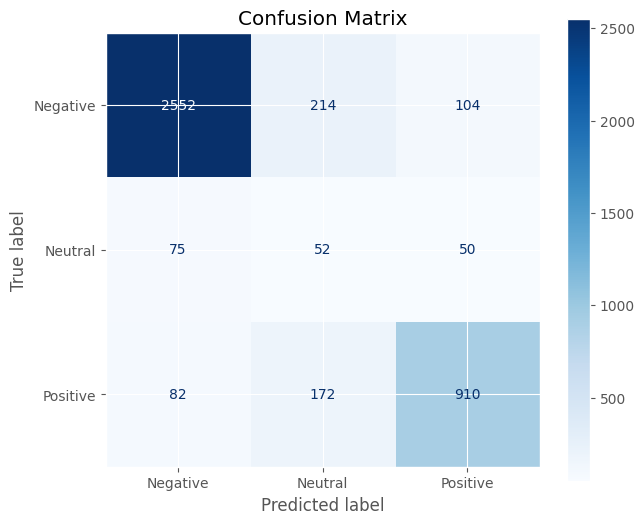

In [11]:
import os

matrix = confusion_matrix(
    y_test,
    prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")

# Create the directory if it doesn't exist
os.makedirs("outputs/figures/", exist_ok=True)

plt.savefig(
    "outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####ROC Curve

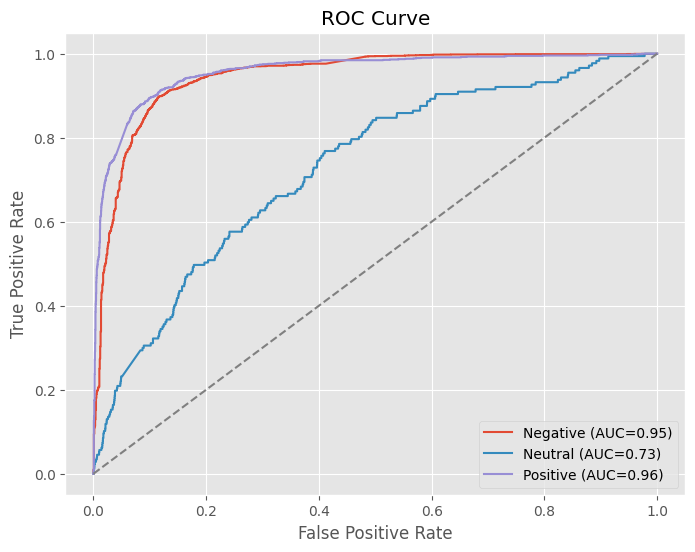

In [12]:
y_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_bin[:,i],
        probability[:,i]
    )

    score = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label_encoder.classes_[i]} (AUC={score:.2f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "outputs/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Precision Recall Curve

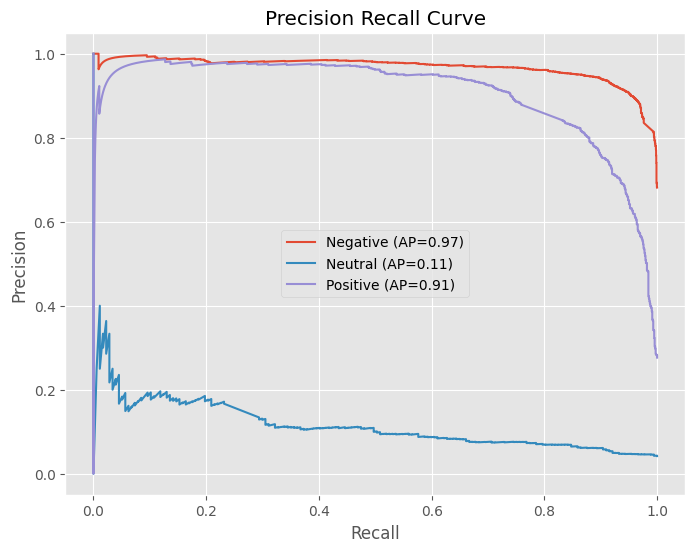

In [13]:
plt.figure(figsize=(8,6))

for i in range(3):

    precision, recall, _ = precision_recall_curve(
        y_bin[:,i],
        probability[:,i]
    )

    ap = average_precision_score(
        y_bin[:,i],
        probability[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{label_encoder.classes_[i]} (AP={ap:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.savefig(
    "outputs/figures/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Learning Curve

In [14]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_test,
    y=y_test,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1,1.0,5)
)

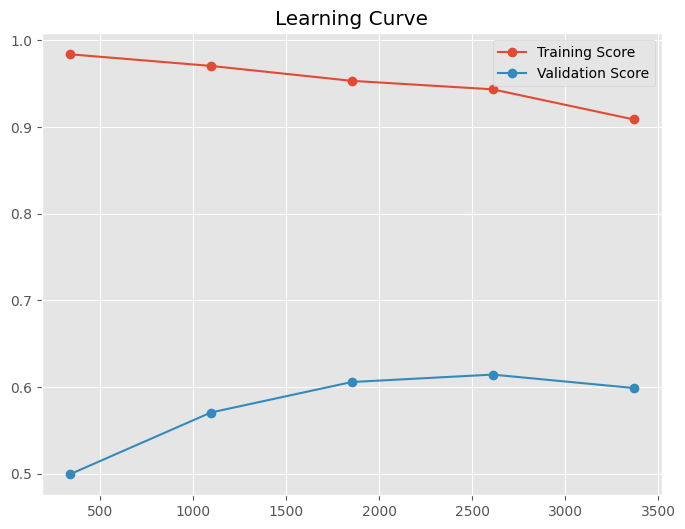

In [15]:
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    marker="o",
    label="Validation Score"
)

plt.legend()

plt.title("Learning Curve")

plt.savefig(
    "outputs/figures/learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Error Analysis

In [16]:
df = pd.read_csv(
    "/content/final_sentiment_dataset.csv"
)

#####Predict

In [19]:
X_all = joblib.load(
    "/content/tfidf_vectorizer.pkl"
).transform(df["cleaned_review"])

df["prediction"] = model.predict(X_all)

df["prediction"] = label_encoder.inverse_transform(
    df["prediction"]
)

#####Find mistakes

In [20]:
errors = df[
    df["prediction"] != df["sentiment"]
]

#####Save

In [22]:
import os

os.makedirs('outputs/reports/', exist_ok=True)
errors.to_csv(
    "outputs/reports/misclassified_reviews.csv",
    index=False
)

#####Most Misclassified Reviews

In [23]:
errors[
    [
        "review",
        "sentiment",
        "prediction",
        "rating",
        "country"
    ]
].head(20)

,review,sentiment,prediction,rating,country
11,I have no interest in signing up to Amazon Pri...,Negative,Neutral,1,GB
32,Often buy through Amazon and never really have...,Positive,Negative,4,GB
81,I have been a Prime member since 2016. In the ...,Negative,Neutral,2,GB
136,I didn’t get my 10 items order from Amazon las...,Negative,Positive,1,CA
147,I gave 4 stars because the majority of drivers...,Positive,Negative,4,GB
160,"I used to like Amazon a lot, in their early ye...",Negative,Neutral,1,US
176,Review text not found,Negative,Neutral,1,GB
184,Review text not found,Negative,Neutral,1,IN
188,Review text not found,Negative,Neutral,2,US
190,"Sometimes things are cheap, sometimes expensiv...",Positive,Neutral,4,GB


####Model Performance Summary

In [24]:
summary = pd.DataFrame({

"Metric":[
"Accuracy",
"Macro F1",
"Weighted F1"
],

"Value":[

report["accuracy"],

report["macro avg"]["f1-score"],

report["weighted avg"]["f1-score"]

]

})

summary

,Metric,Value
0,Accuracy,0.834481
1,Macro F1,0.633614
2,Weighted F1,0.856429


####Save

In [26]:
import os

os.makedirs('outputs/metrics/', exist_ok=True)
summary.to_csv(
    "outputs/metrics/final_metrics.csv",
    index=False
)

####Model Evaluation Summary

In [27]:
print("=" * 60)
print("MODEL EVALUATION SUMMARY")
print("=" * 60)
print(f"Accuracy       : {report['accuracy']:.3f}")
print(f"Macro F1       : {report['macro avg']['f1-score']:.3f}")
print(f"Weighted F1    : {report['weighted avg']['f1-score']:.3f}")
print(f"Best Model     : Logistic Regression")
print("=" * 60)

MODEL EVALUATION SUMMARY
Accuracy       : 0.834
Macro F1       : 0.634
Weighted F1    : 0.856
Best Model     : Logistic Regression
